# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [ ]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
print(f'Số dòng: {df.shape[0]:,}')
print(f'Số cột: {df.shape[1]}')
print('\nTên cột:')
print(df.columns.tolist())
print('\nKiểu dữ liệu:')
print(df.dtypes)
df.describe(include='all').T

Số dòng: 541,909
Số cột: 8

Tên cột:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Kiểu dữ liệu:
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## A.2. Missing values & Duplicate data

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()
print('Giá trị thiếu theo cột:')
print(missing)
print(f'\nSố dòng trùng lặp hoàn toàn: {duplicates:,}')

Giá trị thiếu theo cột:
CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

Số dòng trùng lặp hoàn toàn: 5,268


## A.3. Invalid values

In [8]:
invalid_summary = pd.Series({
    'Quantity <= 0': (df['Quantity'] <= 0).sum(),
    'UnitPrice <= 0': (df['UnitPrice'] <= 0).sum(),
    'InvoiceNo bắt đầu bằng C': df['InvoiceNo'].astype(str).str.startswith('C').sum(),
    'Description thiếu': df['Description'].isna().sum(),
    'CustomerID thiếu': df['CustomerID'].isna().sum()
})
print('Các dấu hiệu/giá trị không hợp lệ:')
print(invalid_summary)
print('\nTỷ lệ trên toàn bộ dữ liệu (%):')
print((invalid_summary / len(df) * 100).round(2))

Các dấu hiệu/giá trị không hợp lệ:
Quantity <= 0                10624
UnitPrice <= 0                2517
InvoiceNo bắt đầu bằng C      9288
Description thiếu             1454
CustomerID thiếu            135080
dtype: int64

Tỷ lệ trên toàn bộ dữ liệu (%):
Quantity <= 0                1.96
UnitPrice <= 0               0.46
InvoiceNo bắt đầu bằng C     1.71
Description thiếu            0.27
CustomerID thiếu            24.93
dtype: float64


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [9]:
clean_df = df.loc[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
clean_df['Sales'] = clean_df['Quantity'] * clean_df['UnitPrice']
print(f'Dữ liệu trước làm sạch: {len(df):,} dòng')
print(f'Dữ liệu sau làm sạch: {len(clean_df):,} dòng')
print(f'Dòng đã loại: {len(df) - len(clean_df):,}')
clean_df.head()

Dữ liệu trước làm sạch: 541,909 dòng
Dữ liệu sau làm sạch: 530,104 dòng
Dòng đã loại: 11,805


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [16]:
central_tendency = pd.DataFrame({
    'Mean': [clean_df['Quantity'].mean(), clean_df['UnitPrice'].mean(), clean_df['Sales'].mean()],
    'Median': [clean_df['Quantity'].median(), clean_df['UnitPrice'].median(), clean_df['Sales'].median()],
    'Mode': [clean_df['Quantity'].mode().iloc[0], clean_df['UnitPrice'].mode().iloc[0], clean_df['Sales'].mode().iloc[0]]
}, index=['Quantity', 'UnitPrice', 'Sales'])
central_tendency.round(2)

,Mean,Median,Mode
Quantity,10.54,3.00,1.00
UnitPrice,3.91,2.08,1.25
Sales,20.12,9.90,15.00


## Group 2 — Dispersion

In [18]:
dispersion = pd.DataFrame({
    'Variance': [clean_df[col].var() for col in ['Quantity', 'UnitPrice', 'Sales']],
    'Std': [clean_df[col].std() for col in ['Quantity', 'UnitPrice', 'Sales']],
    'Range': [clean_df[col].max() - clean_df[col].min() for col in ['Quantity', 'UnitPrice', 'Sales']],
    'IQR': [clean_df[col].quantile(.75) - clean_df[col].quantile(.25) for col in ['Quantity', 'UnitPrice', 'Sales']]
}, index=['Quantity', 'UnitPrice', 'Sales'])
dispersion.round(2)

,Variance,Std,Range,IQR
Quantity,24187.75,155.52,80994.00,9.00
UnitPrice,1289.94,35.92,13541.33,2.88
Sales,73092.77,270.36,168469.60,13.95


## Group 3 — Location and Shape

In [20]:
shape = pd.DataFrame({
    'Skewness': [clean_df[col].skew() for col in ['Quantity', 'UnitPrice', 'Sales']],
    'Kurtosis': [clean_df[col].kurtosis() for col in ['Quantity', 'UnitPrice', 'Sales']],
    'Q1': [clean_df[col].quantile(.25) for col in ['Quantity', 'UnitPrice', 'Sales']],
    'Q3': [clean_df[col].quantile(.75) for col in ['Quantity', 'UnitPrice', 'Sales']]
}, index=['Quantity', 'UnitPrice', 'Sales'])
shape.round(2)

,Skewness,Kurtosis,Q1,Q3
Quantity,471.73,236462.34,1.00,10.00
UnitPrice,206.09,62483.14,1.25,4.13
Sales,506.71,297651.66,3.75,17.70


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

Quốc gia doanh thu cao nhất: United Kingdom
Doanh thu: £9,025,222.08
Tỷ trọng: 84.61%


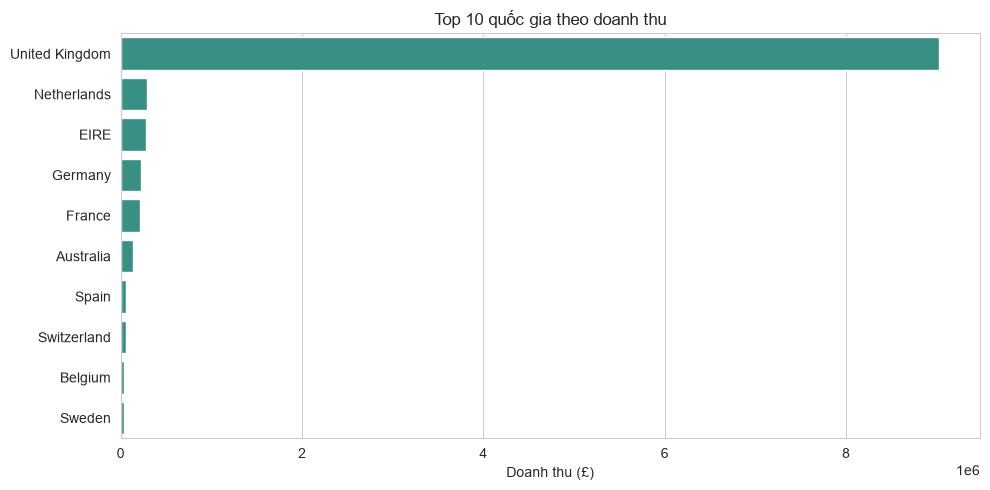

In [21]:
country_sales = clean_df.groupby('Country', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
top_country = country_sales.iloc[0]
total_sales = country_sales['Sales'].sum()
print(f"Quốc gia doanh thu cao nhất: {top_country['Country']}")
print(f"Doanh thu: £{top_country['Sales']:,.2f}")
print(f"Tỷ trọng: {top_country['Sales'] / total_sales:.2%}")

plt.figure(figsize=(10, 5))
sns.barplot(data=country_sales.head(10), x='Sales', y='Country', color='#2a9d8f')
plt.title('Top 10 quốc gia theo doanh thu')
plt.xlabel('Doanh thu (£)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [ ]:
product_sales = (clean_df.groupby(['StockCode', 'Description'], dropna=False, as_index=False)['Sales']
                .sum().sort_values('Sales', ascending=False))
print('Sản phẩm bán chạy nhất theo doanh thu:')
product_sales.head(10)

Sản phẩm bán chạy nhất theo doanh thu:


,StockCode,Description,Sales
4150,DOT,DOTCOM POSTAGE,206248.77
1340,22423,REGENCY CAKESTAND 3 TIER,174484.74
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104340.29
2877,47566,PARTY BUNTING,99504.33
3619,85099B,JUMBO BAG RED RETROSPOT,94340.05
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
4151,M,Manual,78110.27
4153,POST,POSTAGE,78101.88
2029,23084,RABBIT NIGHT LIGHT,66964.99


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

Doanh thu theo tháng:
     Month       Sales MonthName
2010-12-01  823746.140   2010-12
2011-01-01  691364.560   2011-01
2011-02-01  523631.890   2011-02
2011-03-01  717639.360   2011-03
2011-04-01  537808.621   2011-04
2011-05-01  770536.020   2011-05
2011-06-01  761739.900   2011-06
2011-07-01  719221.191   2011-07
2011-08-01  759138.380   2011-08
2011-09-01 1058590.172   2011-09
2011-10-01 1154979.300   2011-10
2011-11-01 1509496.330   2011-11
2011-12-01  638792.680   2011-12


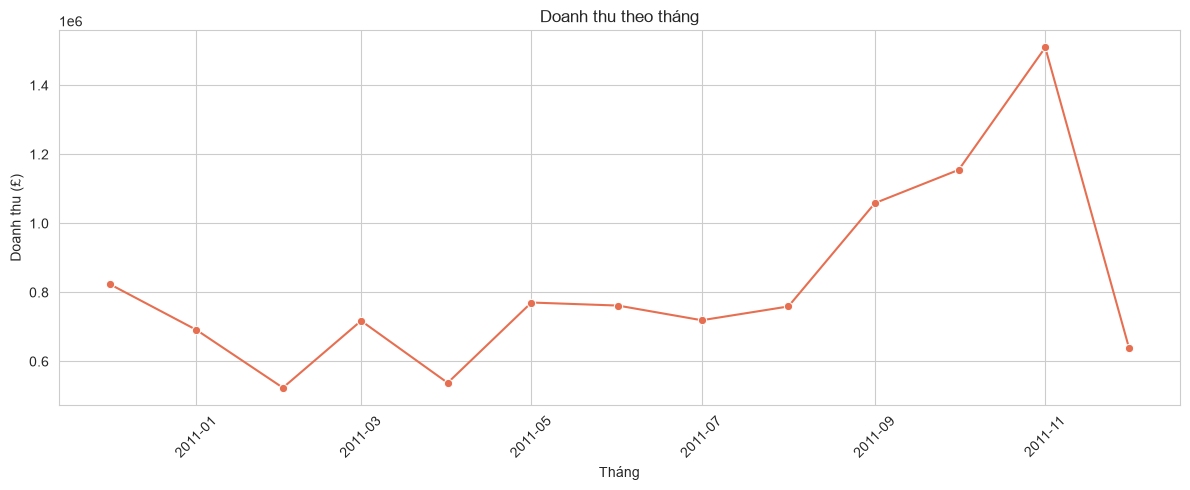


Nhận xét: Biểu đồ cho thấy doanh thu biến động theo tháng; cần thận trọng khi gọi là mùa vụ vì dữ liệu chỉ bao phủ khoảng một năm.


In [15]:
monthly_sales = (clean_df.assign(Month=clean_df['InvoiceDate'].dt.to_period('M').dt.to_timestamp())
                .groupby('Month', as_index=False)['Sales'].sum())
monthly_sales['MonthName'] = monthly_sales['Month'].dt.strftime('%Y-%m')
print('Doanh thu theo tháng:')
print(monthly_sales.to_string(index=False))

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o', color='#e76f51')
plt.title('Doanh thu theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Doanh thu (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print('\nNhận xét: Biểu đồ cho thấy doanh thu biến động theo tháng; cần thận trọng khi gọi là mùa vụ vì dữ liệu chỉ bao phủ khoảng một năm.')

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [17]:
order_sales = clean_df.groupby(['Country', 'InvoiceNo'], as_index=False)['Sales'].sum()
aov_by_country = (order_sales.groupby('Country', as_index=False)
                  .agg(AOV=('Sales', 'mean'), Orders=('InvoiceNo', 'nunique'))
                  .sort_values('AOV', ascending=False))
print('AOV theo quốc gia (ưu tiên quốc gia có ít nhất 10 đơn):')
aov_by_country.query('Orders >= 10').head(15).round(2)

AOV theo quốc gia (ưu tiên quốc gia có ít nhất 10 đơn):


,Country,AOV,Orders
24,Netherlands,3036.66,94
0,Australia,2430.20,57
20,Japan,1969.28,19
16,Hong Kong,1426.53,11
32,Sweden,1066.06,36
33,Switzerland,1057.22,54
9,Denmark,1053.07,18
25,Norway,1004.60,36
10,EIRE,984.22,288
7,Cyprus,849.40,16


## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [19]:
returns = df['Quantity'] < 0
return_rate_by_country = (df.assign(IsReturn=returns)
                          .groupby('Country')
                          .agg(TotalTransactions=('InvoiceNo', 'size'),
                               ReturnTransactions=('IsReturn', 'sum')))
return_rate_by_country['ReturnRate'] = (return_rate_by_country['ReturnTransactions'] /
                                        return_rate_by_country['TotalTransactions'])
return_rate_by_country = return_rate_by_country.sort_values('ReturnRate', ascending=False)
print('Tỷ lệ giao dịch có Quantity âm theo quốc gia (ít nhất 10 giao dịch):')
return_rate_by_country.query('TotalTransactions >= 10').head(15).assign(
    ReturnRate=lambda x: x['ReturnRate'].map('{:.2%}'.format)
)

Tỷ lệ giao dịch có Quantity âm theo quốc gia (ít nhất 10 giao dịch):


,TotalTransactions,ReturnTransactions,ReturnRate
Country,,,
USA,291,112,38.49%
Czech Republic,30,5,16.67%
Malta,127,15,11.81%
Japan,358,37,10.34%
Saudi Arabia,10,1,10.00%
Australia,1259,74,5.88%
Italy,803,45,5.60%
Bahrain,19,1,5.26%
Germany,9495,453,4.77%


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Dữ liệu có 541.909 giao dịch thuộc 38 quốc gia; CustomerID và Description là hai trường thiếu đáng kể, đồng thời dữ liệu có nhiều dòng trùng lặp cần lưu ý khi phân tích. Sau khi loại Quantity <= 0 và UnitPrice <= 0, cột Sales được tạo bằng Quantity * UnitPrice để phản ánh doanh thu của giao dịch hợp lệ. Phân phối Quantity, UnitPrice và Sales lệch phải, thể hiện một số ít giao dịch có giá trị rất lớn so với phần lớn giao dịch còn lại, vì vậy median và IQR hữu ích hơn mean khi mô tả điển hình. United Kingdom là thị trường đóng góp doanh thu lớn nhất, còn nhóm sản phẩm dẫn đầu doanh thu nên được ưu tiên khi đánh giá danh mục. Doanh thu biến động theo tháng và có dấu hiệu tăng mạnh ở các tháng cuối kỳ, nhưng cần thêm nhiều năm dữ liệu để kết luận chắc chắn về mùa vụ; tỷ lệ Quantity âm cũng khác nhau giữa các quốc gia và nên được theo dõi như tín hiệu hoàn/hủy.